# Spline-CLT vs Linear CLT: Multi-Seed Comparison

Results from the `neurips_core_gpt2` paper run (3 variants × 3 seeds = 9 checkpoints).

**Variants compared:**
- `spline_default_gpt2` — Spline-CLT (KAN encoder, d_transcoder=4096)
- `linear_param_match_gpt2` — Linear CLT matched to Spline-CLT parameter count
- `linear_feature_match_gpt2` — Linear CLT matched on d_transcoder=4096

**Metrics covered:**
1. Reconstruction quality (MSE, cosine similarity, relative error) — all seeds
2. Sparsity (active features per position, activation density)
3. Monosemanticity (Gini coefficients)
4. Per-seed consistency and variance
5. Spline shape analysis — KAN only (seed 101)
6. Circuit tracing on a prompt — KAN vs Linear (seed 101)

> **Note on NaN metrics in aggregate_metrics.json:** `prompt_metrics.error_count=60` for all
> variants/seeds — circuit tracing failed during the paper run. Those sections are omitted here;
> reconstruction and monosemanticity metrics are fully valid (500 samples each).

## 0. Configuration

In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Repo root ─────────────────────────────────────────────────────────────────
REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), ".."))).resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── NeurIPS run root ──────────────────────────────────────────────────────────
SUITE_ROOT = REPO_ROOT / "results" / "paper" / "neurips_core_gpt2"
RUNS_ROOT  = SUITE_ROOT / "runs"
DATA_DIR   = str(SUITE_ROOT / "shared" / "activations" / "gpt2")

# ── Variants and seeds ────────────────────────────────────────────────────────
SEEDS = [101, 202, 303]

VARIANTS = {
    "Spline-CLT":           "spline_default_gpt2",
    "Linear (param-match)": "linear_param_match_gpt2",
    "Linear (feat-match)":  "linear_feature_match_gpt2",
}

COLORS = {
    "Spline-CLT":           "steelblue",
    "Linear (param-match)": "coral",
    "Linear (feat-match)":  "mediumseagreen",
}

# ── Interactive analysis settings ─────────────────────────────────────────────
INTERACTIVE_SEED  = 101
PROMPT            = "The Eiffel Tower is located in"
MAX_FEATURES      = 64
N_SPLINE_FEATURES = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float32

print(f"Suite root : {SUITE_ROOT}")
print(f"Data dir   : {DATA_DIR}")
print(f"Seeds      : {SEEDS}")
print(f"Variants   : {list(VARIANTS.keys())}")
print(f"Device     : {DEVICE}")

Suite root : /home/sureshm/circuit-tracer/results/paper/neurips_core_gpt2
Data dir   : /home/sureshm/circuit-tracer/results/paper/neurips_core_gpt2/shared/activations/gpt2
Seeds      : [101, 202, 303]
Variants   : ['Spline-CLT', 'Linear (param-match)', 'Linear (feat-match)']
Device     : cuda


## 1. Load All Evaluation Summaries

Read the pre-computed `evaluation_summary.json` for every variant × seed (9 files).
No model loading required for this section.

In [2]:
# summaries[label][seed] = evaluation_summary dict
summaries: dict[str, dict[int, dict]] = {}

for label, variant_dir in VARIANTS.items():
    summaries[label] = {}
    for seed in SEEDS:
        path = RUNS_ROOT / variant_dir / f"seed_{seed}" / "evaluation" / "evaluation_summary.json"
        if not path.exists():
            print(f"  [MISSING] {label} seed={seed}: {path}")
            continue
        with open(path) as f:
            summaries[label][seed] = json.load(f)
        r = summaries[label][seed]["reconstruction"]
        print(f"  {label:<26} seed={seed}  "
              f"MSE={r['mse_total']:.4f}  "
              f"cos_sim={r['cosine_similarity']:.4f}  "
              f"rel_err={r['relative_error']:.4f}")

total = sum(len(v) for v in summaries.values())
print(f"\nLoaded {total}/9 summaries.")

  Spline-CLT                 seed=101  MSE=0.9964  cos_sim=0.3395  rel_err=0.3763
  Spline-CLT                 seed=202  MSE=0.9918  cos_sim=0.3528  rel_err=0.3751
  Spline-CLT                 seed=303  MSE=1.0101  cos_sim=0.3263  rel_err=0.3786
  Linear (param-match)       seed=101  MSE=43.2200  cos_sim=0.1290  rel_err=2.4780
  Linear (param-match)       seed=202  MSE=43.7648  cos_sim=0.1280  rel_err=2.4917
  Linear (param-match)       seed=303  MSE=43.5660  cos_sim=0.1280  rel_err=2.4865
  Linear (feat-match)        seed=101  MSE=15.7163  cos_sim=0.1686  rel_err=1.4933
  Linear (feat-match)        seed=202  MSE=15.6773  cos_sim=0.1681  rel_err=1.4902
  Linear (feat-match)        seed=303  MSE=16.0044  cos_sim=0.1670  rel_err=1.5060

Loaded 9/9 summaries.


## 2. Reconstruction Quality — Mean ± Std Across Seeds

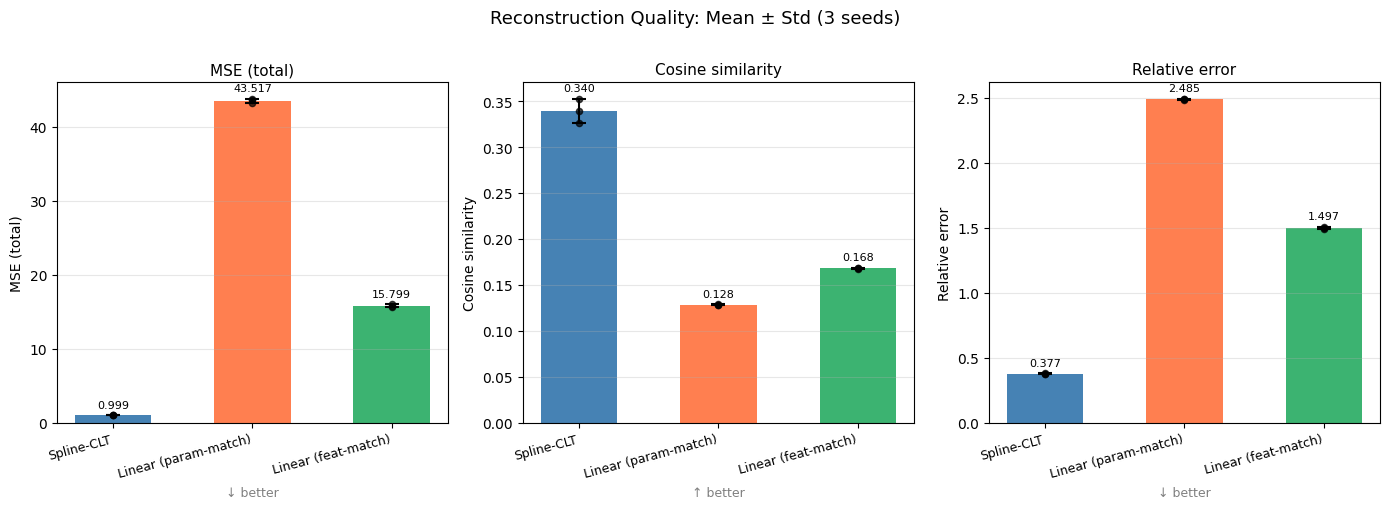

In [3]:
def recon_values(label: str, key: str) -> list[float]:
    return [summaries[label][s]["reconstruction"][key] for s in SEEDS if s in summaries[label]]

recon_cfg = [
    ("MSE (total)",       "mse_total",         True),
    ("Cosine similarity", "cosine_similarity",  False),
    ("Relative error",    "relative_error",     True),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = np.arange(len(VARIANTS))

for ax, (title, key, lower_better) in zip(axes, recon_cfg):
    means = [np.mean(recon_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(recon_values(lbl, key), ddof=1) for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("\u2193 better" if lower_better else "\u2191 better", fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        ax.scatter([i] * len(SEEDS), recon_values(lbl, key),
                   color="black", s=20, zorder=5, alpha=0.7)

fig.suptitle("Reconstruction Quality: Mean \u00b1 Std (3 seeds)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

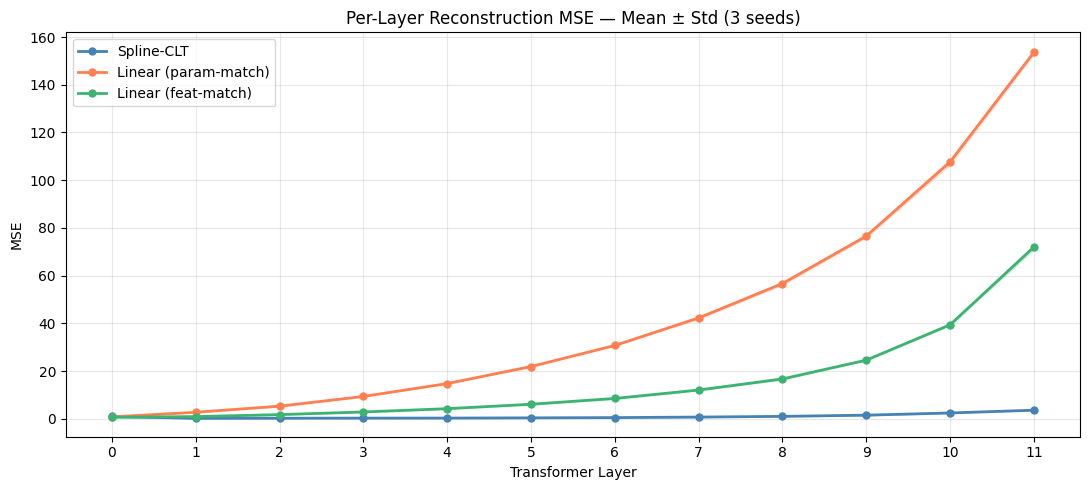

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

for label in VARIANTS:
    per_layer = np.array([
        summaries[label][s]["reconstruction"]["mse_per_layer"]
        for s in SEEDS if s in summaries[label]
    ])  # (n_seeds, n_layers)
    mean = per_layer.mean(axis=0)
    std  = per_layer.std(axis=0, ddof=1)
    xs   = np.arange(len(mean))
    ax.plot(xs, mean, marker="o", label=label, color=COLORS[label], linewidth=2, markersize=5)
    ax.fill_between(xs, mean - std, mean + std, alpha=0.18, color=COLORS[label])

ax.set_xlabel("Transformer Layer")
ax.set_ylabel("MSE")
ax.set_title("Per-Layer Reconstruction MSE — Mean \u00b1 Std (3 seeds)")
ax.set_xticks(np.arange(12))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Sparsity — Active Features & Activation Density

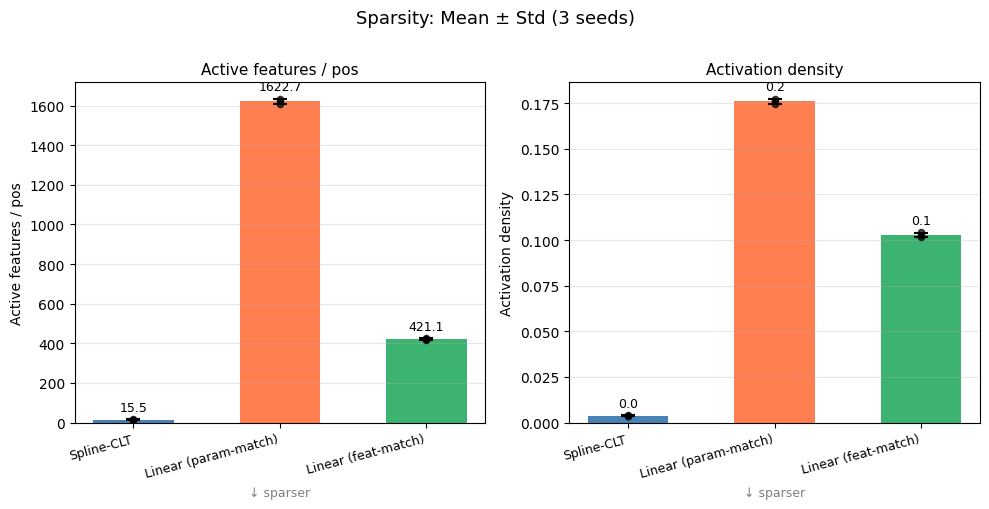


Parameter counts (seed 101):
  Spline-CLT                : 622,961,664
  Linear (param-match)      : 637,240,320
  Linear (feat-match)       : 283,223,040


In [5]:
sparsity_cfg = [
    ("Active features / pos", "active_per_pos",     True),
    ("Activation density",    "activation_density", True),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
x = np.arange(len(VARIANTS))

for ax, (title, key, lower_better) in zip(axes, sparsity_cfg):
    means = [np.mean(recon_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(recon_values(lbl, key), ddof=1) for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("\u2193 sparser", fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        ax.scatter([i] * len(SEEDS), recon_values(lbl, key),
                   color="black", s=20, zorder=5, alpha=0.7)

fig.suptitle("Sparsity: Mean \u00b1 Std (3 seeds)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nParameter counts (seed 101):")
for label in VARIANTS:
    if 101 in summaries[label]:
        n = summaries[label][101]["reconstruction"]["n_params"]
        print(f"  {label:<26}: {n:,}")

## 4. Monosemanticity — Gini Coefficients

Higher Gini = feature fires more selectively (more monosemantic). Evaluated on 200 features per variant per seed.

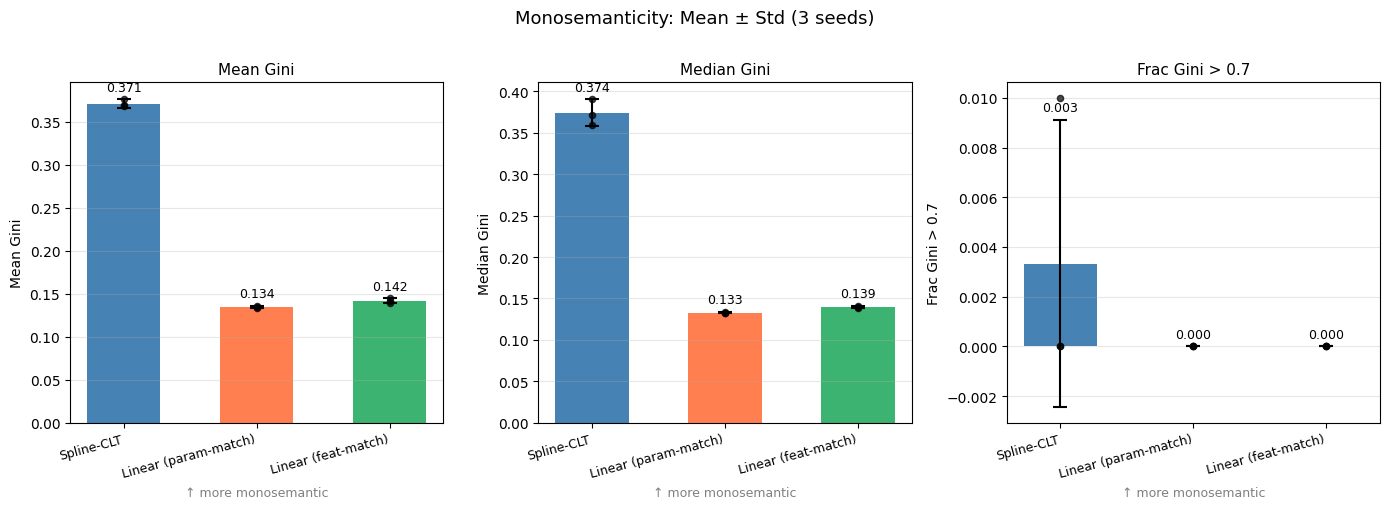

In [6]:
def gini_values(label: str, key: str) -> list[float]:
    return [summaries[label][s]["monosemanticity"][key] for s in SEEDS if s in summaries[label]]

gini_cfg = [
    ("Mean Gini",         "mean_gini",            False),
    ("Median Gini",       "median_gini",           False),
    ("Frac Gini > 0.7",   "fraction_gini_gt_0_7",  False),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = np.arange(len(VARIANTS))

for ax, (title, key, _) in zip(axes, gini_cfg):
    means = [np.mean(gini_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(gini_values(lbl, key), ddof=1) for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("\u2191 more monosemantic", fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        ax.scatter([i] * len(SEEDS), gini_values(lbl, key),
                   color="black", s=20, zorder=5, alpha=0.7)

fig.suptitle("Monosemanticity: Mean \u00b1 Std (3 seeds)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Seed Consistency Table

In [7]:
metrics_cfg = [
    ("MSE (total)",      lambda s: s["reconstruction"]["mse_total"],          ".4f"),
    ("Cosine sim",       lambda s: s["reconstruction"]["cosine_similarity"],   ".4f"),
    ("Relative error",   lambda s: s["reconstruction"]["relative_error"],      ".4f"),
    ("Active / pos",     lambda s: s["reconstruction"]["active_per_pos"],      ".1f"),
    ("Density",          lambda s: s["reconstruction"]["activation_density"],  ".5f"),
    ("Mean Gini",        lambda s: s["monosemanticity"]["mean_gini"],          ".4f"),
    ("Median Gini",      lambda s: s["monosemanticity"]["median_gini"],        ".4f"),
]

labels = list(VARIANTS.keys())
print(f"{'Metric':<20}" + "".join(f"  {lbl:<34}" for lbl in labels))
print("-" * (20 + len(labels) * 36))

for name, extractor, fmt in metrics_cfg:
    row = f"{name:<20}"
    for lbl in labels:
        vals = [extractor(summaries[lbl][s]) for s in SEEDS if s in summaries[lbl]]
        per_seed = "  ".join(f"{v:{fmt}}" for v in vals)
        row += f"  {per_seed}  (\u03bc={np.mean(vals):{fmt}})"
    print(row)

Metric                Spline-CLT                          Linear (param-match)                Linear (feat-match)               
--------------------------------------------------------------------------------------------------------------------------------
MSE (total)           0.9964  0.9918  1.0101  (μ=0.9995)  43.2200  43.7648  43.5660  (μ=43.5169)  15.7163  15.6773  16.0044  (μ=15.7993)
Cosine sim            0.3395  0.3528  0.3263  (μ=0.3395)  0.1290  0.1280  0.1280  (μ=0.1283)  0.1686  0.1681  0.1670  (μ=0.1679)
Relative error        0.3763  0.3751  0.3786  (μ=0.3767)  2.4780  2.4917  2.4865  (μ=2.4854)  1.4933  1.4902  1.5060  (μ=1.4965)
Active / pos          15.3  15.0  16.2  (μ=15.5)  1610.2  1635.9  1622.0  (μ=1622.7)  420.1  416.3  426.9  (μ=421.1)
Density               0.00375  0.00366  0.00396  (μ=0.00379)  0.17472  0.17751  0.17600  (μ=0.17608)  0.10256  0.10162  0.10423  (μ=0.10280)
Mean Gini             0.3676  0.3688  0.3769  (μ=0.3711)  0.1333  0.1340  0.1357  (μ=0.13

## 6. Scatter: Reconstruction vs Monosemanticity

Each dot = one (variant, seed). ★ = mean. Good models: low MSE + high Gini.

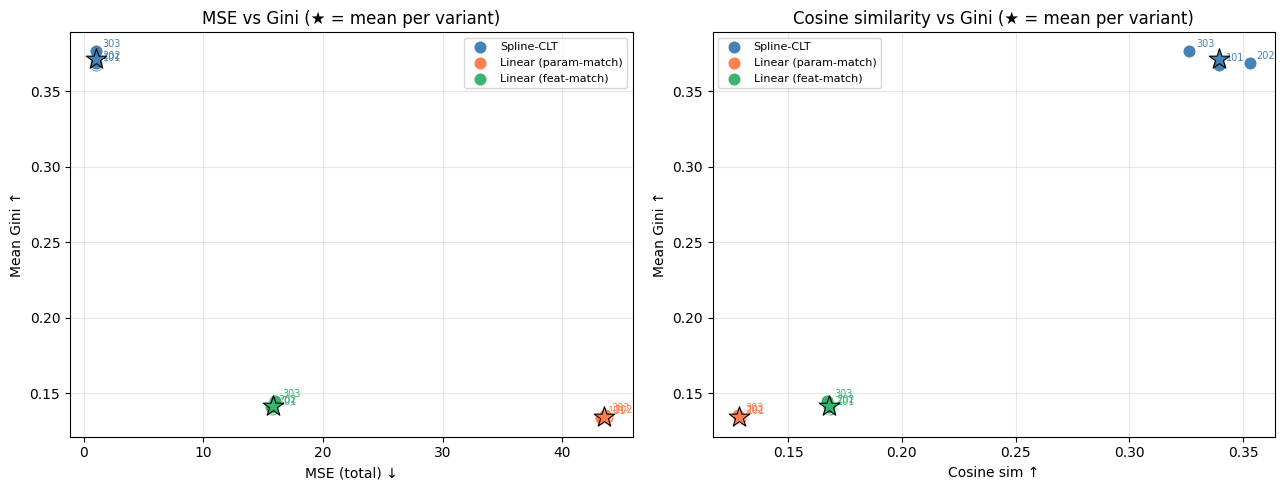

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (xsection, xkey, ysection, ykey, xlabel, ylabel) in zip(axes, [
    ("reconstruction", "mse_total",        "monosemanticity", "mean_gini", "MSE (total) \u2193", "Mean Gini \u2191"),
    ("reconstruction", "cosine_similarity", "monosemanticity", "mean_gini", "Cosine sim \u2191",  "Mean Gini \u2191"),
]):
    for lbl in VARIANTS:
        xs = [summaries[lbl][s][xsection][xkey] for s in SEEDS if s in summaries[lbl]]
        ys = [summaries[lbl][s][ysection][ykey] for s in SEEDS if s in summaries[lbl]]
        ax.scatter(xs, ys, color=COLORS[lbl], s=90, zorder=5, label=lbl,
                   edgecolors="white", linewidths=0.8)
        ax.scatter([np.mean(xs)], [np.mean(ys)], color=COLORS[lbl],
                   s=240, marker="*", zorder=6, edgecolors="black", linewidths=0.8)
        for s, x, y in zip(SEEDS, xs, ys):
            ax.annotate(str(s), (x, y), textcoords="offset points",
                        xytext=(5, 3), fontsize=7, color=COLORS[lbl])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

axes[0].set_title("MSE vs Gini (\u2605 = mean per variant)")
axes[1].set_title("Cosine similarity vs Gini (\u2605 = mean per variant)")
plt.tight_layout()
plt.show()

---
## 7. Spline Analysis — KAN Encoder (seed 101)

Loads the Spline-CLT checkpoint and visualises learned B-spline transfer functions.
Requires GPU/CPU with enough RAM and the activation dataset.

**Shape interpretation:**
- Straight line → linear behaviour (no KAN benefit)
- Step / threshold → detects when input crosses a value
- Peak / bump → responds to a specific input range
- Polynomial curve → genuinely nonlinear function

In [9]:
from spline_clt.kan_transcoder import load_spline_clt
from spline_clt.utils import count_parameters

_spline_ckpt = (RUNS_ROOT / "spline_default_gpt2"
                / f"seed_{INTERACTIVE_SEED}" / "checkpoints"
                / f"spline_clt_gpt2_seed{INTERACTIVE_SEED}_best")
_linear_ckpt = (RUNS_ROOT / "linear_param_match_gpt2"
                / f"seed_{INTERACTIVE_SEED}" / "checkpoints"
                / f"linear_param_gpt2_seed{INTERACTIVE_SEED}_best")

models = {}
for label, ckpt in [("Spline-CLT", _spline_ckpt), ("Linear (param-match)", _linear_ckpt)]:
    if not ckpt.exists():
        print(f"[MISSING] {label}: {ckpt}")
        continue
    print(f"Loading {label} from {ckpt.name} ...")
    m = load_spline_clt(str(ckpt), device=DEVICE, dtype=DTYPE)
    m.eval()
    models[label] = m
    print(f"  encoder_type={m.encoder_type}  d_transcoder={m.d_transcoder}"
          f"  params={count_parameters(m):,}")

kan_model    = models.get("Spline-CLT")
linear_model = models.get("Linear (param-match)")

Loading Spline-CLT from spline_clt_gpt2_seed101_best ...


  encoder_type=kan  d_transcoder=4096  params=622,961,664
Loading Linear (param-match) from linear_param_gpt2_seed101_best ...


  encoder_type=linear  d_transcoder=9216  params=637,240,320


In [10]:
from experiments.analyze_splines import collect_feature_stats, extract_spline_curve, top_input_dims
from spline_clt.training.data import ActivationDataset

if kan_model is None:
    print("Spline-CLT not loaded — skipping spline analysis.")
    dataset = top_features = freq = None
else:
    print(f"Loading dataset from {DATA_DIR} ...")
    dataset = ActivationDataset.load(DATA_DIR, max_samples=250)
    print(f"  {len(dataset)} sequences loaded")

    print("Collecting KAN feature statistics ...")
    spline_stats = collect_feature_stats(kan_model, dataset, DEVICE, torch.float32, n_samples=200)
    freq = spline_stats["activation_frequency"]  # (n_layers, d_transcoder)

    flat_freq   = freq.reshape(-1)
    top_indices = flat_freq.topk(N_SPLINE_FEATURES).indices
    top_features = [
        (int(idx // kan_model.d_transcoder), int(idx % kan_model.d_transcoder))
        for idx in top_indices
    ]
    print(f"Top {N_SPLINE_FEATURES} features: {top_features}")

Loading dataset from /home/sureshm/circuit-tracer/results/paper/neurips_core_gpt2/shared/activations/gpt2 ...
  250 sequences loaded


Top 6 features: [(10, 1250), (10, 2811), (10, 4050), (10, 1935), (10, 877), (10, 1736)]


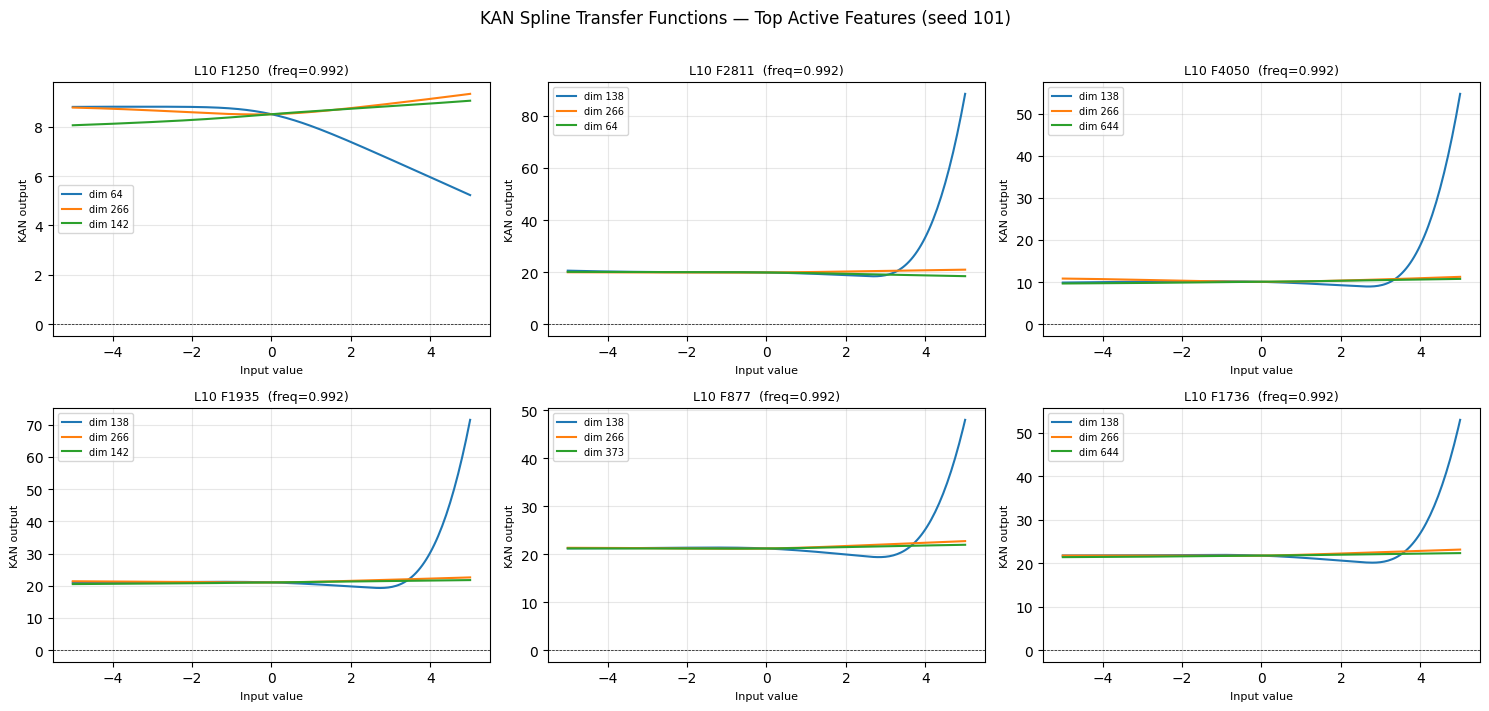

Nonlinearity (residual/variance — higher = more nonlinear):
  L10 F877     0.8163  <- nonlinear
  L10 F1736    0.7913  <- nonlinear
  L10 F1935    0.7590  <- nonlinear
  L10 F2811    0.7448  <- nonlinear
  L10 F4050    0.7394  <- nonlinear
  L10 F1250    0.1696  <- nonlinear


In [11]:
if kan_model is not None and top_features is not None:
    n_cols = 3
    n_rows = int(np.ceil(N_SPLINE_FEATURES / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)

    for plot_idx, (layer_id, feature_id) in enumerate(top_features):
        ax = axes[plot_idx // n_cols][plot_idx % n_cols]
        f_freq = freq[layer_id, feature_id].item()
        try:
            dims = top_input_dims(kan_model, layer_id, feature_id, top_k=3)
            for dim in dims:
                t_vals, curve = extract_spline_curve(kan_model, layer_id, feature_id, dim, device=DEVICE)
                ax.plot(t_vals, curve, label=f"dim {dim}", linewidth=1.5)
            ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
            ax.set_title(f"L{layer_id} F{feature_id}  (freq={f_freq:.3f})", fontsize=9)
            ax.set_xlabel("Input value", fontsize=8); ax.set_ylabel("KAN output", fontsize=8)
            ax.legend(fontsize=7); ax.grid(alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color="red")
            ax.set_title(f"L{layer_id} F{feature_id}", fontsize=9)

    for i in range(N_SPLINE_FEATURES, n_rows * n_cols):
        axes[i // n_cols][i % n_cols].set_visible(False)

    fig.suptitle(f"KAN Spline Transfer Functions — Top Active Features (seed {INTERACTIVE_SEED})",
                 fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()

    # Nonlinearity scores
    scores = []
    for layer_id, feature_id in top_features:
        try:
            dims = top_input_dims(kan_model, layer_id, feature_id, top_k=1)
            t_vals, curve = extract_spline_curve(kan_model, layer_id, feature_id, dims[0],
                                                  n_points=200, device=DEVICE)
            coeffs = np.polyfit(t_vals, curve, 1)
            residual = np.mean((curve - np.polyval(coeffs, t_vals)) ** 2)
            nonlin = residual / (np.var(curve) + 1e-8)
            scores.append((layer_id, feature_id, nonlin))
        except Exception:
            continue

    scores.sort(key=lambda x: x[2], reverse=True)
    print("Nonlinearity (residual/variance — higher = more nonlinear):")
    for layer_id, feature_id, score in scores:
        tag = "  <- nonlinear" if score > 0.05 else ""
        print(f"  L{layer_id} F{feature_id:<6}  {score:.4f}{tag}")

## 8. Circuit Tracing on a Prompt (seed 101)

In [12]:
from experiments.run_circuit import collect_activations_for_prompt
from attribution.causal import build_attribution_graph

attributions = {}

if not models:
    print("No models loaded — skipping circuit tracing.")
else:
    first_model = next(iter(models.values()))
    print(f"Prompt: {PROMPT!r}")
    mlp_inputs, mlp_outputs, tokens = collect_activations_for_prompt(
        model_name="gpt2",
        prompt=PROMPT,
        n_layers=first_model.n_layers,
        device=DEVICE,
        feature_input_hook=first_model.feature_input_hook,
        feature_output_hook=first_model.feature_output_hook,
    )
    mlp_inputs  = mlp_inputs.to(dtype=DTYPE)
    mlp_outputs = mlp_outputs.to(dtype=DTYPE)
    print(f"Tokens: {tokens}")

    for label, model in models.items():
        print(f"Running causal attribution for {label} ...")
        with torch.no_grad():
            attr = build_attribution_graph(model, mlp_inputs, max_features=MAX_FEATURES)
        attributions[label] = attr
        print(f"  {len(attr['active_features'])} active features")

Prompt: 'The Eiffel Tower is located in'


Loading gpt2 with TransformerLens...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Running forward pass: 9 tokens...
Tokens: ['<|endoftext|>', 'The', ' E', 'iff', 'el', ' Tower', ' is', ' located', ' in']
Running causal attribution for Spline-CLT ...


Ablating features:   0%|          | 0/64 [00:00<?, ?it/s]

...

Ablating features:  88%|████████▊ | 56/64 [00:01<00:00, 35.11it/s]

Ablating features:  94%|█████████▍| 60/64 [00:01<00:00, 35.38it/s]

Ablating features: 100%|██████████| 64/64 [00:01<00:00, 35.24it/s]

Ablating features: 100%|██████████| 64/64 [00:01<00:00, 34.37it/s]

  64 active features


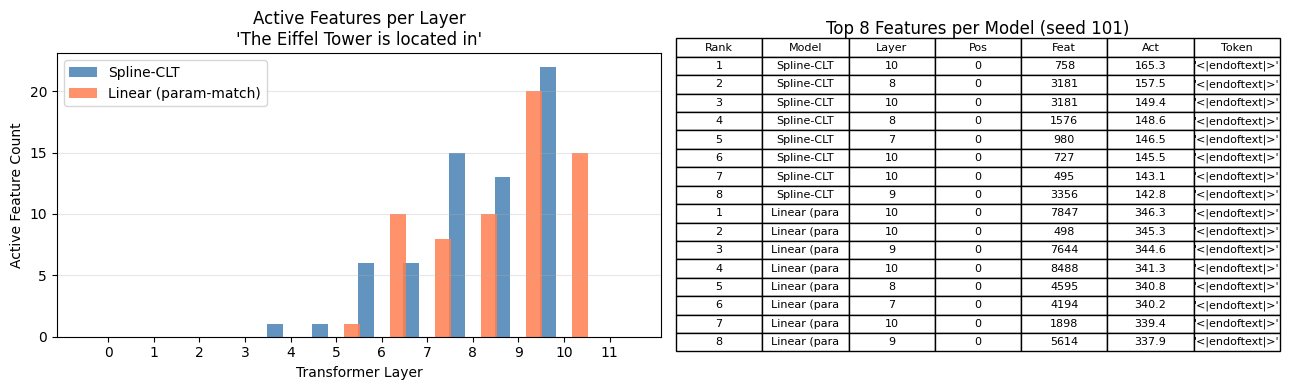

In [13]:
if attributions:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Active features by layer
    ax = axes[0]
    n_layers = first_model.n_layers
    x = np.arange(n_layers)
    bar_w = 0.35
    offsets = np.linspace(-bar_w, bar_w, len(attributions))
    for offset, (label, attr) in zip(offsets, attributions.items()):
        layers = attr["active_features"][:, 0].cpu().numpy()
        counts = np.bincount(layers, minlength=n_layers)
        ax.bar(x + offset, counts, width=bar_w, label=label,
               color=COLORS.get(label, "grey"), alpha=0.85)
    ax.set_xlabel("Transformer Layer"); ax.set_ylabel("Active Feature Count")
    ax.set_title(f"Active Features per Layer\n{PROMPT!r}")
    ax.set_xticks(x); ax.legend(); ax.grid(alpha=0.3, axis="y")

    # Top-8 features table
    ax = axes[1]; ax.axis("off")
    TOP_K = 8
    rows = [["Rank", "Model", "Layer", "Pos", "Feat", "Act", "Token"]]
    for label, attr in attributions.items():
        active = attr["active_features"]
        values = attr["activation_values"]
        for rank, i in enumerate(values.abs().argsort(descending=True)[:TOP_K], 1):
            layer = active[i, 0].item(); pos = active[i, 1].item(); feat = active[i, 2].item()
            tok = tokens[pos] if pos < len(tokens) else "?"
            rows.append([str(rank), label[:12], str(layer), str(pos),
                         str(feat), f"{values[i].item():.1f}", repr(tok)])
    tbl = ax.table(cellText=rows[1:], colLabels=rows[0], loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.2)
    ax.set_title(f"Top {TOP_K} Features per Model (seed {INTERACTIVE_SEED})", pad=14)

    plt.tight_layout(); plt.show()

## 9. Summary Table

In [14]:
print("\n" + "=" * 82)
print("  Spline-CLT vs Linear CLT — Aggregate Summary (mean \u00b1 std, 3 seeds)".center(82))
print("=" * 82)

summary_rows = [
    ("--- Reconstruction ---",       None),
    ("MSE (total) \u2193",           ("reconstruction",   "mse_total")),
    ("Cosine similarity \u2191",      ("reconstruction",   "cosine_similarity")),
    ("Relative error \u2193",         ("reconstruction",   "relative_error")),
    ("--- Sparsity ---",              None),
    ("Active features / pos \u2193",  ("reconstruction",   "active_per_pos")),
    ("Activation density \u2193",     ("reconstruction",   "activation_density")),
    ("--- Monosemanticity ---",       None),
    ("Mean Gini \u2191",              ("monosemanticity",  "mean_gini")),
    ("Median Gini \u2191",            ("monosemanticity",  "median_gini")),
    ("Frac Gini > 0.7 \u2191",        ("monosemanticity",  "fraction_gini_gt_0_7")),
]

labels = list(VARIANTS.keys())
col_w  = 28
hdr = f"  {'Metric':<36}" + "".join(f"{l:>{col_w}}" for l in labels)
print(hdr)
print("  " + "-" * (len(hdr) - 2))

for name, key_path in summary_rows:
    if key_path is None:
        print(f"\n  {name}")
        continue
    section, key = key_path
    row = f"  {name:<36}"
    for lbl in labels:
        vals = [summaries[lbl][s][section][key] for s in SEEDS if s in summaries[lbl]]
        row += f"{np.mean(vals):>{col_w//2}.4f} \u00b1 {np.std(vals, ddof=1):<{col_w//2-3}.4f}"
    print(row)

print("\n" + "=" * 82)
print(f"  Seeds: {SEEDS}")
print("  n_params: " + " | ".join(
    f"{lbl}: {summaries[lbl][101]['reconstruction']['n_params']:,}"
    for lbl in labels if 101 in summaries[lbl]
))


         Spline-CLT vs Linear CLT — Aggregate Summary (mean ± std, 3 seeds)       
  Metric                                                Spline-CLT        Linear (param-match)         Linear (feat-match)
  ------------------------------------------------------------------------------------------------------------------------

  --- Reconstruction ---
  MSE (total) ↓                               0.9995 ± 0.0095            43.5169 ± 0.2757            15.7993 ± 0.1787     
  Cosine similarity ↑                         0.3395 ± 0.0132             0.1283 ± 0.0005             0.1679 ± 0.0008     
  Relative error ↓                            0.3767 ± 0.0018             2.4854 ± 0.0069             1.4965 ± 0.0084     

  --- Sparsity ---
  Active features / pos ↓                    15.5148 ± 0.6382          1622.7277 ± 12.8565          421.0848 ± 5.3957     
  Activation density ↓                        0.0038 ± 0.0002             0.1761 ± 0.0014             0.1028 ± 0.0013     

  --- Mo